Deep Learning Task 1

Written By: Karin Fridkin and Rotem Trabelsi

Description: building a simple neural network “from scratch”.

In [18]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from dnn_model import l_layer_model, predict,l_model_forward

In [19]:
def load_and_preprocess_mnist(number_of_classes = 10):
    # Load
    (x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data(path='mnist.npz')
    
    # Flatten: (60000, 28, 28) -> (784, 60000) and normalize to [0, 1]
    x_train_full = x_train_full.reshape(-1, 784).T / 255.0
    x_test       = x_test.reshape(-1, 784).T       / 255.0
    
    # One-hot encode labels: (60000,) -> (10, 60000)
    y_train_full = np.eye(number_of_classes)[y_train_full].T
    y_test       = np.eye(number_of_classes)[y_test].T
    
    # Split train -> train (80%) + validation (20%)
    m             = x_train_full.shape[1]
    m_val         = int(m * 0.2)
    
    np.random.seed(42)
    permutation   = np.random.permutation(m)
    train_idx     = permutation[m_val:]
    val_idx       = permutation[:m_val]
    
    x_train, y_train = x_train_full[:, train_idx], y_train_full[:, train_idx]
    x_val,   y_val   = x_train_full[:, val_idx],   y_train_full[:, val_idx]
    
    # Summary
    print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
    
    return x_train, y_train, x_val, y_val, x_test, y_test

In [20]:
x_train, y_train, x_val, y_val, x_test, y_test = load_and_preprocess_mnist()

Train: (784, 48000) | Val: (784, 12000) | Test: (784, 10000)


In [21]:
LAYER_DIMS    = [784, 20, 7, 5, 10]
LEARNING_RATE = 0.009
BATCH_SIZE    = 512
NUM_ITERATIONS = 100 

parameters, costs = l_layer_model(
    x_train, y_train,
    layers_dims    = LAYER_DIMS,
    learning_rate  = LEARNING_RATE,
    num_iterations = NUM_ITERATIONS,
    batch_size     = BATCH_SIZE,
    use_batchnorm  = False,
    X_val          = x_val,
    Y_val          = y_val
)

training steps 100 | Train Cost: 1.938374 | Val Cost: 1.943917
training steps 200 | Train Cost: 1.772671 | Val Cost: 1.778619
training steps 300 | Train Cost: 1.676960 | Val Cost: 1.682073
training steps 400 | Train Cost: 1.604905 | Val Cost: 1.608717
training steps 500 | Train Cost: 1.539283 | Val Cost: 1.542075
training steps 600 | Train Cost: 1.473078 | Val Cost: 1.474182
training steps 700 | Train Cost: 1.406857 | Val Cost: 1.406153
training steps 800 | Train Cost: 1.339614 | Val Cost: 1.337508
training steps 900 | Train Cost: 1.273200 | Val Cost: 1.269717
training steps 1000 | Train Cost: 1.210733 | Val Cost: 1.205924
training steps 1100 | Train Cost: 1.151971 | Val Cost: 1.146111
training steps 1200 | Train Cost: 1.097312 | Val Cost: 1.090536
training steps 1300 | Train Cost: 1.045580 | Val Cost: 1.038559
training steps 1400 | Train Cost: 0.995188 | Val Cost: 0.988128
training steps 1500 | Train Cost: 0.949184 | Val Cost: 0.941859
training steps 1600 | Train Cost: 0.906013 | Val 

In [22]:
train_accuracy = predict(x_train, y_train, parameters)
val_accuracy   = predict(x_val,   y_val,   parameters)
test_accuracy  = predict(x_test,  y_test,  parameters)

print(f" train accuracy:     {train_accuracy * 100:.2f}%")
print(f" validation accuracy:  {val_accuracy * 100:.2f}%")
print(f" test accuracy:       {test_accuracy * 100:.2f}%")

 train accuracy:     93.31%
 validation accuracy:  92.56%
 test accuracy:       92.58%


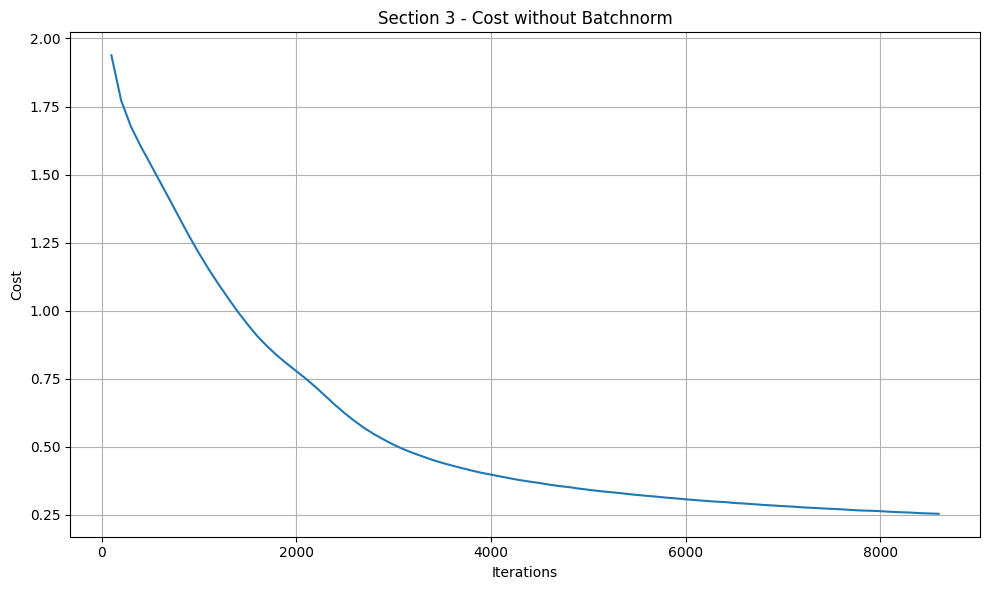

In [23]:
def plot_costs(costs, learning_rate, title="Cost over Training"):
    plt.figure(figsize=(10, 6))
    
    iterations = [i * 100 for i in range(1, len(costs) + 1)]
    
    plt.plot(iterations, costs)
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_costs(costs, learning_rate=0.009, title="Section 3 - Cost without Batchnorm")

In [24]:
# Batch Normalization Backpropagation (znormi):
# We calculate the gradient of the cost with respect to Z by considering 
# the influence of each Zi on the batch mean and variance. 
# This ensures the chain rule is preserved through the normalization step.

LAYER_DIMS    = [784, 20, 7, 5, 10]
LEARNING_RATE = 0.009
BATCH_SIZE    = 512
NUM_ITERATIONS = 300 

parameters_bn, costs_bn = l_layer_model(
    x_train, y_train,
    layers_dims    = LAYER_DIMS,
    learning_rate  = LEARNING_RATE,
    num_iterations = NUM_ITERATIONS,
    batch_size     = BATCH_SIZE,
    use_batchnorm  = True,
    X_val          = x_val,
    Y_val          = y_val
)

training steps 100 | Train Cost: 1.859572 | Val Cost: 1.864058
training steps 200 | Train Cost: 1.713019 | Val Cost: 1.716478
training steps 300 | Train Cost: 1.646548 | Val Cost: 1.649480
training steps 400 | Train Cost: 1.603570 | Val Cost: 1.606172
training steps 500 | Train Cost: 1.570697 | Val Cost: 1.573199
training steps 600 | Train Cost: 1.543190 | Val Cost: 1.545301
training steps 700 | Train Cost: 1.518649 | Val Cost: 1.520780
training steps 800 | Train Cost: 1.495772 | Val Cost: 1.497967
training steps 900 | Train Cost: 1.473901 | Val Cost: 1.476105
training steps 1000 | Train Cost: 1.452215 | Val Cost: 1.454336
training steps 1100 | Train Cost: 1.431119 | Val Cost: 1.433058
training steps 1200 | Train Cost: 1.409817 | Val Cost: 1.411574
training steps 1300 | Train Cost: 1.388026 | Val Cost: 1.389875
training steps 1400 | Train Cost: 1.366069 | Val Cost: 1.368013
training steps 1500 | Train Cost: 1.343813 | Val Cost: 1.345853
training steps 1600 | Train Cost: 1.321666 | Val 

In [25]:
train_accuracy_bn = predict(x_train, y_train, parameters_bn,True)
val_accuracy_bn   = predict(x_val,   y_val,   parameters_bn,True)
test_accuracy_bn  = predict(x_test,  y_test,  parameters_bn,True)

print(f"Train Accuracy:      {train_accuracy_bn * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy_bn * 100:.2f}%")
print(f"Test Accuracy:       {test_accuracy_bn * 100:.2f}%")

Train Accuracy:      91.42%
Validation Accuracy: 90.33%
Test Accuracy:       89.82%


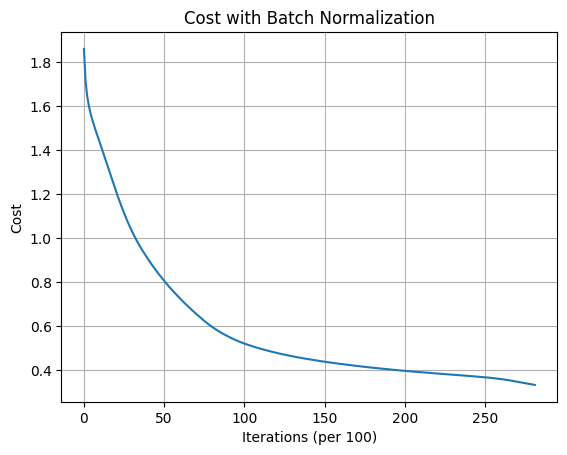

In [26]:
def plot_costs(costs, title="Model Convergence"):
    plt.plot(costs)
    plt.ylabel('Cost')
    plt.xlabel('Iterations (per 100)')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_costs(costs_bn, title="Cost with Batch Normalization")

In [27]:
#l2 norm
#printing the w before l2 and after

LAMBD = 0.1

parameters_l2, costs_l2 = l_layer_model(
    x_train, y_train, 
    layers_dims    = [784, 20, 7, 10], 
    learning_rate  = 0.009, 
    num_iterations = 3000, 
    batch_size     = 512, 
    use_batchnorm  = True, 
    X_val          = x_val, 
    Y_val          = y_val,
    lambd          = LAMBD  
)

training steps 100 | Train Cost: 1.901247 | Val Cost: 1.914331
training steps 200 | Train Cost: 1.573976 | Val Cost: 1.586157
training steps 300 | Train Cost: 1.418622 | Val Cost: 1.428674
training steps 400 | Train Cost: 1.322055 | Val Cost: 1.330778
training steps 500 | Train Cost: 1.253065 | Val Cost: 1.261026
training steps 600 | Train Cost: 1.198695 | Val Cost: 1.205962
training steps 700 | Train Cost: 1.154016 | Val Cost: 1.160762
training steps 800 | Train Cost: 1.115949 | Val Cost: 1.121776
training steps 900 | Train Cost: 1.083147 | Val Cost: 1.088394
training steps 1000 | Train Cost: 1.055056 | Val Cost: 1.060147
training steps 1100 | Train Cost: 1.029241 | Val Cost: 1.034357
training steps 1200 | Train Cost: 1.006056 | Val Cost: 1.011404
training steps 1300 | Train Cost: 0.986182 | Val Cost: 0.991872
training steps 1400 | Train Cost: 0.967298 | Val Cost: 0.972972
training steps 1500 | Train Cost: 0.950579 | Val Cost: 0.956402
training steps 1600 | Train Cost: 0.934971 | Val 

In [28]:
train_accuracy_l2 = predict(x_train, y_train, parameters_l2, use_batchnorm=True)
val_accuracy_l2   = predict(x_val,   y_val,   parameters_l2, use_batchnorm=True)
test_accuracy_l2  = predict(x_test,  y_test,  parameters_l2, use_batchnorm=True)

print("--- L2 Regularization Results ---")
print(f"Train Accuracy:      {train_accuracy_l2 * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy_l2 * 100:.2f}%")
print(f"Test Accuracy:       {test_accuracy_l2 * 100:.2f}%")

--- L2 Regularization Results ---
Train Accuracy:      90.48%
Validation Accuracy: 90.03%
Test Accuracy:       90.70%


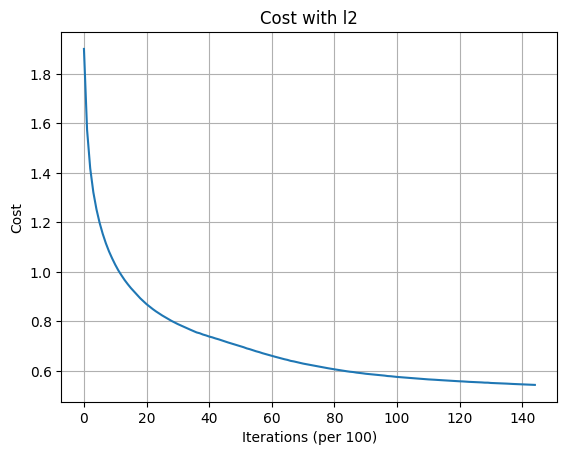

In [29]:
plot_costs(costs_l2, title="Cost with l2")

In [30]:
def compare_weights(params_no_l2, params_l2):
    print("Layer | Avg Weight (No L2) | Avg Weight (With L2)")
    print("-" * 45)
    for l in range(1, len(params_no_l2)//2):
        w_no_l2 = np.mean(np.abs(params_no_l2[f"W{l}"]))
        w_l2    = np.mean(np.abs(params_l2[f"W{l}"]))
        print(f"  {l}   |      {w_no_l2:.6f}      |      {w_l2:.6f}")

compare_weights(parameters_bn, parameters_l2)

Layer | Avg Weight (No L2) | Avg Weight (With L2)
---------------------------------------------
  1   |      0.040117      |      0.039034
  2   |      0.244630      |      0.226303
  3   |      0.547818      |      0.468558


In [ ]:
# compare lambda
lambda_values = [0, 0.01, 0.1, 0.5,1,5] 
results = {}

for l in lambda_values:
    print(f"--- Training with lambda = {l} ---")
    params, _ = l_layer_model(
        x_train, y_train, 
        layers_dims    = [784, 20, 7, 10], 
        learning_rate  = 0.009, 
        num_iterations = 3000, 
        batch_size     = 512, 
        use_batchnorm  = True, 
        X_val          = x_val, 
        Y_val          = y_val,
        lambd          = l  
    )
    results[l] = params



--- Training with lambda = 0 ---
training steps 100 | Train Cost: 1.612777 | Val Cost: 1.624906
training steps 200 | Train Cost: 1.346447 | Val Cost: 1.356250
training steps 300 | Train Cost: 1.201698 | Val Cost: 1.209747
training steps 400 | Train Cost: 1.106279 | Val Cost: 1.114342
training steps 500 | Train Cost: 1.034649 | Val Cost: 1.043011
training steps 600 | Train Cost: 0.977275 | Val Cost: 0.985180
training steps 700 | Train Cost: 0.928411 | Val Cost: 0.935436
training steps 800 | Train Cost: 0.885793 | Val Cost: 0.892144
training steps 900 | Train Cost: 0.847504 | Val Cost: 0.853344
training steps 1000 | Train Cost: 0.814186 | Val Cost: 0.820053
training steps 1100 | Train Cost: 0.784152 | Val Cost: 0.790149
training steps 1200 | Train Cost: 0.757339 | Val Cost: 0.763130
training steps 1300 | Train Cost: 0.732801 | Val Cost: 0.738283
training steps 1400 | Train Cost: 0.709772 | Val Cost: 0.714587
training steps 1500 | Train Cost: 0.689485 | Val Cost: 0.693525
training steps 1

In [ ]:
def compare_all_weights(results_dict):
    lambda_values = sorted(results_dict.keys())
    
    header = f"{'Layer':<10} | {'Baseline (L=0)':<16}"
    for l in lambda_values:
        if l == 0: continue
        header += f" | {'L=' + str(l):<14}"
    
    print(header)
    print("-" * len(header))
    
    first_key = lambda_values[0]
    num_layers = len(results_dict[first_key]) // 2
    
    for l in range(1, num_layers + 1):
        w_base = np.mean(np.abs(results_dict[0][f"W{l}"]))
        row = f"W{l:<8} | {w_base:<16.6f}"
        
        for lb in lambda_values:
            if lb == 0: continue
            w_val = np.mean(np.abs(results_dict[lb][f"W{l}"]))
            row += f" | {w_val:<14.6f}"
        
        print(row)

compare_all_weights(results)

Layer      | Baseline (L=0)   | L=0.01         | L=0.1          | L=0.5          | L=1            | L=5           
------------------------------------------------------------------------------------------------------------------
W1        | 0.039954         | 0.039983       | 0.039034       | 0.035714       | 0.030956       | 0.018560      
W2        | 0.247202         | 0.232163       | 0.226303       | 0.206908       | 0.179564       | 0.106976      
W3        | 0.915510         | 0.468680       | 0.468558       | 0.469986       | 0.470394       | 0.476287      


In [ ]:
def compare_all_accuracies(results_dict, x_train, y_train, x_val, y_val, x_test, y_test):
    print(f"{'Lambda':<10} | {'Train Acc':<12} | {'Val Acc':<12} | {'Test Acc':<12}")
    print("-" * 55)
    
    for lambd in sorted(results_dict.keys()):
        params = results_dict[lambd]
        
        train_acc = predict(x_train, y_train, params, use_batchnorm=True)
        val_acc   = predict(x_val,   y_val,   params, use_batchnorm=True)
        test_acc  = predict(x_test,  y_test,  params, use_batchnorm=True)

        print(f"{lambd:<10} | {train_acc*100:<11.2f}% | {val_acc*100:<11.2f}% | {test_acc*100:<11.2f}%")

compare_all_accuracies(results, x_train, y_train, x_val, y_val, x_test, y_test)

Lambda     | Train Acc    | Val Acc      | Test Acc    
-------------------------------------------------------
0          | 94.82      % | 93.73      % | 93.68      %
0.01       | 90.07      % | 89.59      % | 90.04      %
0.1        | 90.48      % | 90.03      % | 90.70      %
0.5        | 90.36      % | 89.94      % | 90.53      %
1          | 91.10      % | 90.72      % | 91.22      %
5          | 90.85      % | 90.22      % | 90.91      %


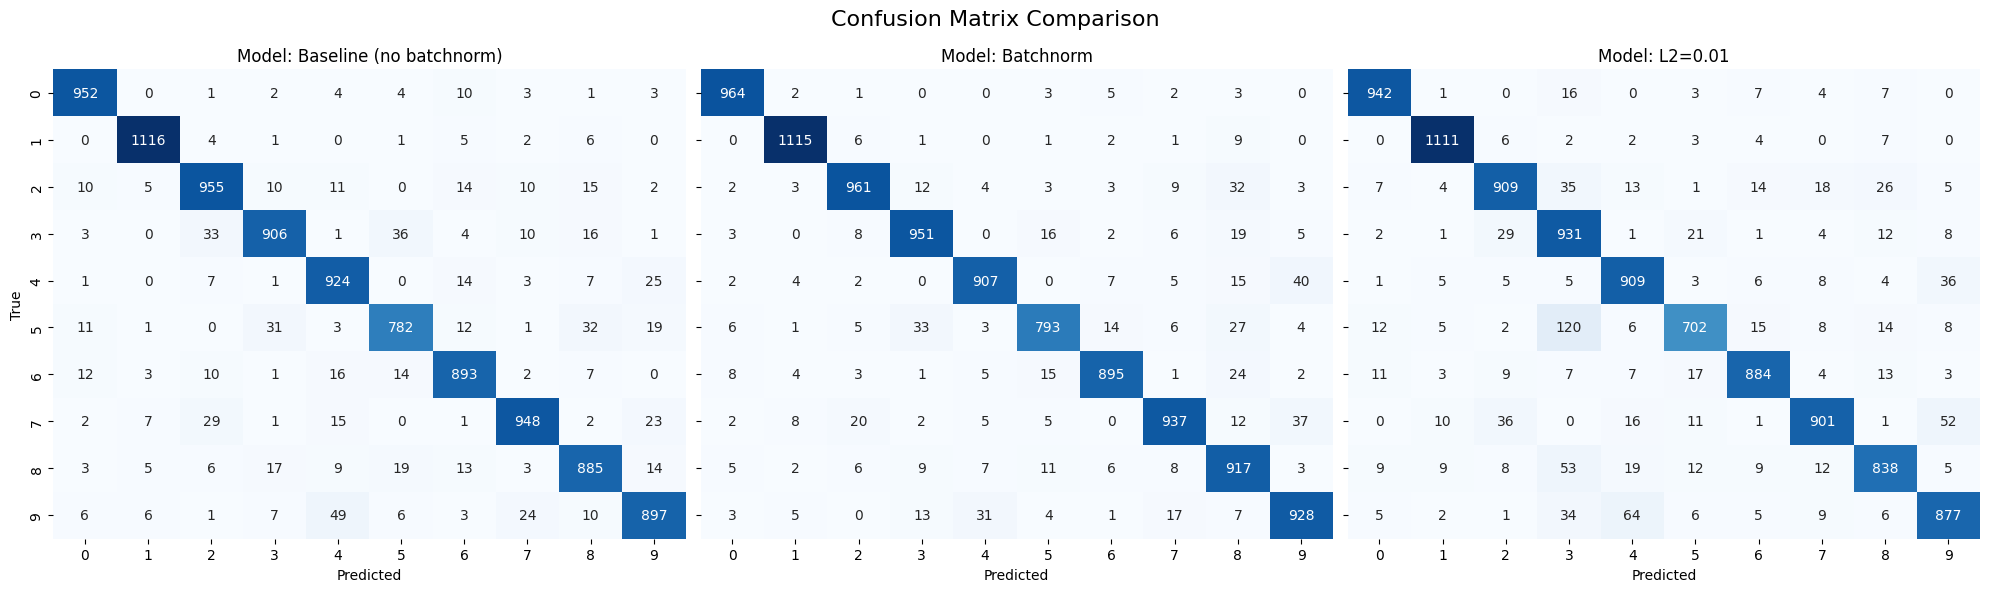

In [ ]:


def plot_three_cms(models_info, x_test, y_test):
    """
    models_info: list of tuples like [('Baseline', params0), ('L2=0.01', params01), ('L2=1', params1)]
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
    
    all_cms = []
    for name, params in models_info:
        use_batchnorm = True
        if name == 'Baseline (no batchnorm)':
            use_batchnorm = False
        AL, _ = l_model_forward(x_test, params, use_batchnorm=use_batchnorm)
        y_pred = np.argmax(AL, axis=0)
        y_true = np.argmax(y_test, axis=0)
        all_cms.append(confusion_matrix(y_true, y_pred))

    # Plotting
    for i, (name, _) in enumerate(models_info):
        sns.heatmap(all_cms[i], annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
        axes[i].set_title(f'Model: {name}')
        axes[i].set_xlabel('Predicted')
        if i == 0:
            axes[i].set_ylabel('True')

    plt.suptitle('Confusion Matrix Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()

# Usage:
models_to_compare = [('Baseline (no batchnorm)', parameters),('Batchnorm', results[0]), ('L2=0.01', results[0.01])]
plot_three_cms(models_to_compare, x_test, y_test)